## 1. What this notebook computes

The previous notebooks of this chapter worked with plane waves in flat 4+4 space (or
with the coefficients frozen at one point). This notebook goes back to the author's
curved metric and looks at the good sector (no dependence on the extra times
$x_5, x_6, x_7$) along the hidden direction $x_8$, with $z = 6Hx_8$ running from
the tip $z = 0$ to the patch end $z = \pi/2$. It

- writes the mode operator $h$ of the field equation for waves that depend only on
  $x_4$ and $x_8$: $i\,\partial_4\Psi = h\Psi$;
- proves exactly (sympy) that $h$ is symmetric for the volume $\cos z\,dx_8$ only up
  to a boundary term $\partial_8(\sin z\,u^\dagger M_8v)$, and that the Krein form is
  conserved only up to a similar term; the term vanishes at the tip but NOT at
  $z = \pi/2$;
- shows that the spin-connection term $3H\gamma^{(x_8)}$ of the field equation is
  exactly what makes the hidden-direction operator symmetric up to that boundary
  term (without it a remainder $-6H\cos z\,u^\dagger M_8v$ survives);
- shows that the waves that do not depend on $x_8$ (they have a finite norm) see the
  matrix $A = -im\gamma^{(x_4)} + 3iH\gamma^{(x_4)}\gamma^{(x_8)}$, with $A^2 = (m^2 -
  9H^2)I_{16}$: for $m < 3H$ their frequencies are imaginary and they grow;
- checks an exact growing solution, and that its Krein charge changes in time by
  exactly the flux through $z = \pi/2$;
- reproduces the recorded numbers and draws five teaching figures.

The message for the chapter: the positive Fock space of the previous notebook is a
construction for flat space (frozen coefficients). In the curved good sector the
evolution is Hermitian, and the Krein charge conserved, only if a boundary condition
is imposed at $z = \pi/2$, and the Revision record imposes none.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 10d (The curved good sector and the boundary at z = pi/2) is the file
`Revision/textbook/notebooks/10d_curved_good_sector.ipynb` of the repository
Dirac_claude. In the author's metric it writes the good-sector mode operator along the
hidden direction, proves exactly with sympy that it is symmetric, and that the Krein form
is conserved, only up to a boundary term that vanishes at the tip z = 0 but not at the
patch end z = pi/2, shows that without the spin-connection term 3 H a remainder survives,
shows that the waves independent of x8 (finite norm) have the frequencies squared m^2 - 9
H^2 and therefore grow for m below 3 H, checks an exact growing solution and that its
Krein charge changes by exactly the flux through z = pi/2, reproduces the recorded
numbers, and draws five teaching figures. It needs a computer with Windows 11, macOS or
Linux, an internet connection for the installation, the program Git, and Python 3.12 or
newer (the notebooks were built with Python 3.14.5) with these packages at exactly these
versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10,
nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook
itself imports numpy, sympy and matplotlib; the other packages run Jupyter, the program
that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 10d_curved_good_sector.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 20 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 10d_curved_good_sector.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
10d_curved_good_sector.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/10d.captions.json`
- `Revision/textbook/figures/10d_1_volume_and_flux.png`
- `Revision/textbook/figures/10d_2_symmetry_defect.png`
- `Revision/textbook/figures/10d_3_frequency_paths.png`
- `Revision/textbook/figures/10d_4_growth_rate.png`
- `Revision/textbook/figures/10d_5_krein_leak.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the figure file 10d_5_krein_leak.png exists
    ALL 16 CHECKS PASSED (notebook 10d)

and the notebook must show 5 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/10d_curved_good_sector.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for gammas.json: the notebook reads one file of the repository; it
  must be opened inside the folder Revision/textbook/notebooks of a complete copy of the
  repository. Clone the repository again and open the notebook there.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 10d (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 10d (The curved good sector and the boundary at z = pi/2) is the file
# Revision/textbook/notebooks/10d_curved_good_sector.ipynb of the repository
# Dirac_claude. In the author's metric it writes the good-sector mode operator along the
# hidden direction, proves exactly with sympy that it is symmetric, and that the Krein
# form is conserved, only up to a boundary term that vanishes at the tip z = 0 but not at
# the patch end z = pi/2, shows that without the spin-connection term 3 H a remainder
# survives, shows that the waves independent of x8 (finite norm) have the frequencies
# squared m^2 - 9 H^2 and therefore grow for m below 3 H, checks an exact growing
# solution and that its Krein charge changes by exactly the flux through z = pi/2,
# reproduces the recorded numbers, and draws five teaching figures. It needs a computer
# with Windows 11, macOS or Linux, an internet connection for the installation, the
# program Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5)
# with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0,
# matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0
# and nbconvert 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the
# other packages run Jupyter, the program that shows and runs notebooks. It does not need
# Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 10d_curved_good_sector.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 20
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 10d_curved_good_sector.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 10d_curved_good_sector.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/10d.captions.json
# - Revision/textbook/figures/10d_1_volume_and_flux.png
# - Revision/textbook/figures/10d_2_symmetry_defect.png
# - Revision/textbook/figures/10d_3_frequency_paths.png
# - Revision/textbook/figures/10d_4_growth_rate.png
# - Revision/textbook/figures/10d_5_krein_leak.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the figure file 10d_5_krein_leak.png exists
#     ALL 16 CHECKS PASSED (notebook 10d)
#
# and the notebook must show 5 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/10d_curved_good_sector.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for gammas.json: the notebook reads one file of the repository;
#   it must be opened inside the folder Revision/textbook/notebooks of a complete copy of
#   the repository. Clone the repository again and open the notebook there.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "10d"  # this notebook: chapter 10, example d


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 10d complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Hidden direction, $z$, tip, patch end**: $x_8$ is the hidden space direction;
  $z = 6Hx_8$ runs over $0 < z < \pi/2$. The *tip* is $z \to 0$, the *patch end* is
  $z = \pi/2$, where the author's metric component $g_{88} = \cot^2 z$ and the volume
  factor $\sqrt{|g|} = \cos z$ vanish.
- **Volume element**: $\sqrt{|g|} = \cos z$; an integral over the hidden direction
  is $\int \cos z\,(\ldots)\,dx_8$.
- **Symmetric operator (formally Hermitian)**: an operator $h$ with
  $\int\cos z\,u^\dagger(hv)\,dx_8 = \int\cos z\,(hu)^\dagger v\,dx_8$ for all
  wave functions $u, v$. A *boundary term* is a part of the integrand that is a
  derivative, $\partial_8(\ldots)$; its integral is the difference of the bracket at
  the two ends, so the operator is symmetric when that difference vanishes.
- **Krein form, Krein charge**: $\int\cos z\,u^\dagger Bv\,dx_8$; for $u = v = \Psi$
  it is the charge of the wave.
- **Flux**: the value of the bracket at an end; a nonzero flux at $z = \pi/2$ means
  that something flows through the patch end (in or out).
- **Boundary condition**: a rule imposed on the wave functions at an end (for
  example that a flux vanishes there); it is an assumption added to the equations.
- **$M_8$**: the matrix $i\gamma^{(x_4)}\gamma^{(x_8)}$.
- **Exponential of a matrix**: $e^{Mx_4} = \sum_n (Mx_4)^n/n!$; if $M^2 = k^2 I$ the
  series collapses to $\cosh(kx_4)I + \frac{\sinh(kx_4)}{k}M$ (even and odd powers).

## 4. The physical and mathematical situation

**The field equation for waves in $x_4$ and $x_8$ only.** The field equation of
dirac16complex in the author's metric (Revision theory record, $U = 0$) is

$$e^{-a_4}\sin^{-1/6}z\sum_{i=1}^3\gamma^{(x_i)}\partial_i\Psi + \gamma^{(x_4)}
\partial_4\Psi + e^{a_4}\sin^{-1/6}z\sum_{t=5}^7\gamma^{(x_t)}\partial_t\Psi +
\tan z\,\gamma^{(x_8)}\partial_8\Psi + 3H\gamma^{(x_8)}\Psi = m\Psi .$$

For a wave that depends only on $x_4$ and $x_8$ the first and third groups vanish:

$$\gamma^{(x_4)}\partial_4\Psi + \tan z\,\gamma^{(x_8)}\partial_8\Psi +
3H\gamma^{(x_8)}\Psi = m\Psi .$$

Multiply from the left by $\gamma^{(x_4)}$, use $(\gamma^{(x_4)})^2 = -1$ and solve
for $\partial_4\Psi$:

$$\partial_4\Psi = -m\gamma^{(x_4)}\Psi + \tan z\,\gamma^{(x_4)}\gamma^{(x_8)}
\partial_8\Psi + 3H\gamma^{(x_4)}\gamma^{(x_8)}\Psi .$$

Multiply by $i$:

$$i\,\partial_4\Psi = h\Psi,\qquad h = A + D\,\partial_8,\qquad
A = -im\gamma^{(x_4)} + 3iH\gamma^{(x_4)}\gamma^{(x_8)},\qquad D = \tan z\,M_8,
\qquad M_8 = i\gamma^{(x_4)}\gamma^{(x_8)} .$$

**Symmetry up to a boundary term, line by line.** Write $u'$ for $\partial_8u$. Then

$$u^\dagger(hv) - (hu)^\dagger v = u^\dagger(A - A^\dagger)v + u^\dagger Dv' -
u'^\dagger D^\dagger v .$$

The notebook checks that $M_8$ is anti-Hermitian, so $D^\dagger = -D$ ($\tan z$ is
real), and the last two terms are $u^\dagger Dv' + u'^\dagger Dv =
(u^\dagger Dv)' - u^\dagger D'v$ (product rule). Multiply by $\cos z$. The notebook
checks the two matrix identities $\cos z\,D = \sin z\,M_8$ and
$\cos z\,(A - A^\dagger) = (\sin z)'M_8$; with them (and the product rule
$(\cos z\,D)' = (\cos z)'D + \cos z\,D'$) everything collects into one derivative:

$$\cos z\,\big[u^\dagger(hv) - (hu)^\dagger v\big] = \partial_8\big(\sin z\;
u^\dagger M_8 v\big).$$

Integrated over $0 < z < \pi/2$ this is $[\sin z\,u^\dagger M_8v]$ at $z = \pi/2$
minus its value at $z = 0$. At the tip $\sin z = 0$; at the patch end $\sin z = 1$,
so the flux $u^\dagger M_8v$ there does not vanish in general. The term
$3iH\gamma^{(x_4)}\gamma^{(x_8)}$ of $A$ (the spin-connection term $3H\gamma^{(x_8)}$
of the field equation) supplies exactly $A - A^\dagger = 6HM_8$, which is needed
because $(\sin z)' = 6H\cos z$.

**Waves that do not depend on $x_8$.** For them $\partial_8\Psi = 0$ and $h$ acts as
the constant matrix $A$. Their norm $\int_0^{\pi/(12H)}\cos(6Hx_8)\,dx_8 = 1/(6H)$ is
finite (the patch $0 < z < \pi/2$ is $0 < x_8 < \pi/(12H)$), so they are honest
members of the good sector. The notebook proves $A^2 = (m^2 - 9H^2)I_{16}$: for
$m < 3H$ the frequencies are imaginary and these waves grow.

## 5. The matrices of the hidden direction

The next cell reads the gammas, builds $C$ and $B$ with numpy and as exact sympy
matrices, defines the symbols $m$, $H$ (positive) and $x_8$, the expression
$z = 6Hx_8$, and the matrices $M_8$, $A$ and $D$ of Section 4. It also defines
`check_record` (the PASS line and the line of the reproduced Revision record are
printed in one piece, so that the stored output is the same in every run) and the
colours. Then it checks the matrix facts of Section 4 exactly:
$M_8^\dagger = -M_8$, $\cos z\,D = \sin z\,M_8$ and $\cos z\,(A - A^\dagger) =
\partial_8(\sin z)\,M_8$, and in addition that $B$ commutes with $\gamma^{(x_4)}$ and
$\gamma^{(x_8)}$. The last fact gives the Krein version: $B$ then commutes with $A$,
$A^\dagger$, $D$ and $M_8$, so the same steps with $u^\dagger B$ in place of
$u^\dagger$ give $\cos z\,[u^\dagger B(hv) - (hu)^\dagger Bv] = \partial_8(\sin z\,
u^\dagger BM_8v)$.

In [2]:
import contextlib  # lets a block of code print into a text buffer
import io  # the text buffer
import sys  # the screen output, sys.stdout

import numpy as np  # numbers, arrays and matrices
import sympy as sp  # exact algebra with symbols


def check_record(condition, name, record):
    """check(condition, name, record=record), printed in one piece."""
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):  # what check prints goes to buffer
        check(condition, name, record=record)
    sys.stdout.write(buffer.getvalue())  # one single piece of output


BLUE, ORANGE, GREEN, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#52514e"
fixture = json.loads(repository_file("Revision/algebra/gammas.json").read_text(
    encoding="utf-8"))
gamma = {a: np.array(fixture["gamma"][a - 1], dtype=float) for a in range(1, 9)}
C = gamma[8] @ gamma[1] @ gamma[2] @ gamma[3]
B = -1j * (C @ gamma[4])  # B = -i C gamma^(x4)
g = {a: sp.Matrix(fixture["gamma"][a - 1]) for a in range(1, 9)}  # exact gammas
B_exact = -sp.I * g[8] * g[1] * g[2] * g[3] * g[4]

m = sp.Symbol("m", real=True)  # the mass
H = sp.Symbol("H", positive=True)  # the author's constant H > 0
x8 = sp.Symbol("x8", real=True)  # the hidden coordinate
z = 6 * H * x8  # z = 6 H x8
M8 = sp.I * g[4] * g[8]  # M_8 = i gamma^(x4) gamma^(x8)
A = -sp.I * m * g[4] + 3 * sp.I * H * g[4] * g[8]  # the part without derivative
A_no_connection = -sp.I * m * g[4]  # the same without the term 3 H
D = sp.tan(z) * M8  # the coefficient of the derivative d/dx8
zero = sp.zeros(16, 16)
anti_hermitian = M8.H == -M8
identity_D = (sp.cos(z) * D - sp.sin(z) * M8).applyfunc(sp.simplify) == zero
identity_A = (sp.cos(z) * (A - A.H) - sp.diff(sp.sin(z), x8) * M8).applyfunc(
    sp.simplify) == zero
B_commutes = (B_exact * g[4] == g[4] * B_exact) and (B_exact * g[8] == g[8] * B_exact)
say(f"M8 anti-Hermitian: {anti_hermitian}; cos z D = sin z M8: {identity_D}; "
    f"cos z (A - A^dagger) = d8(sin z) M8: {identity_A}; B commutes with "
    f"gamma^(x4) and gamma^(x8): {B_commutes}")
check(anti_hermitian and identity_D and identity_A and B_commutes,
      "exact: the four matrix identities of the hidden direction")

M8 anti-Hermitian: True; cos z D = sin z M8: True; cos z (A - A^dagger) = d8(sin z) M8:
    True; B commutes with gamma^(x4) and gamma^(x8): True
PASS exact: the four matrix identities of the hidden direction


## 6. Symmetric up to a boundary term, checked on wave functions

The matrix identities prove the statement of Section 4 for all wave functions. The
next cell also checks it directly on two concrete wave functions $u(x_8)$ and
$v(x_8)$: each of their 16 entries is a combination $a + b\sin z + c\cos z$ with
small whole numbers $a, b, c$ (real and imaginary parts chosen at random with a
fixed seed). It computes, exactly,

- the defect $\cos z\,[u^\dagger(hv) - (hu)^\dagger v] - \partial_8(\sin z\,u^\dagger
  M_8v)$, which must be 0;
- the same with the operator WITHOUT the spin-connection term, which must equal
  $-6H\cos z\,u^\dagger M_8v$ instead;
- the Krein version $\cos z\,[u^\dagger B(hv) - (hu)^\dagger Bv] - \partial_8(\sin z
  \,u^\dagger BM_8v)$, which must be 0.

To let sympy recognise the zeros, $x_8$ is replaced by $z/(6H)$ and the
trigonometric functions are expanded before simplifying.

In [3]:
rng = np.random.default_rng(12345)


def test_function():
    """16 entries a + b sin z + c cos z with small random whole numbers."""
    def number():
        return int(rng.integers(-3, 4)) + sp.I * int(rng.integers(-3, 4))
    return sp.Matrix([number() + number() * sp.sin(z) + number() * sp.cos(z)
                      for _ in range(16)])


def apply_h(matrix_A, w):
    """h w = A w + D dw/dx8 for a column w of functions of x8."""
    return matrix_A * w + D * w.diff(x8)


def is_zero(expression):
    """Exact zero test: write x8 = z / (6 H), expand the trigonometric functions."""
    zz = sp.Symbol("zz")
    rewritten = sp.expand_trig(sp.expand(expression.subs(x8, zz / (6 * H))))
    return sp.simplify(rewritten) == 0


u, v = test_function(), test_function()
hv, hu = apply_h(A, v), apply_h(A, u)
defect = (sp.cos(z) * ((u.H * hv)[0] - (hu.H * v)[0])
          - sp.diff(sp.sin(z) * (u.H * M8 * v)[0], x8))
hv0, hu0 = apply_h(A_no_connection, v), apply_h(A_no_connection, u)
defect_without = (sp.cos(z) * ((u.H * hv0)[0] - (hu0.H * v)[0])
                  - sp.diff(sp.sin(z) * (u.H * M8 * v)[0], x8))
remainder_ok = is_zero(defect_without + 6 * H * sp.cos(z) * (u.H * M8 * v)[0])
krein_defect = (sp.cos(z) * ((u.H * B_exact * hv)[0] - (hu.H * B_exact * v)[0])
                - sp.diff(sp.sin(z) * (u.H * B_exact * M8 * v)[0], x8))
check_record(is_zero(defect),
             "exact: cos z (u^dagger h v - (h u)^dagger v) = d8(sin z u^dagger M8 v)",
             record="Revision/theory/reports/python-scope.json, check "
                    "good_sector_hermiticity_up_to_the_brane_flux")
check_record(remainder_ok,
             "exact: without the term 3 H the remainder -6 H cos z u^dagger M8 v stays",
             record="Revision/theory/reports/wolfram-field-theory.json, check "
                    "good_sector_hermiticity_curved")
check_record(is_zero(krein_defect),
             "exact: the Krein form is conserved up to d8(sin z u^dagger B M8 v)",
             record="Revision/theory/reports/wolfram-field-theory.json, check "
                    "Krein_form_conserved_curved")

PASS exact: cos z (u^dagger h v - (h u)^dagger v) = d8(sin z u^dagger M8 v)
     reproduces Revision/theory/reports/python-scope.json, check
    good_sector_hermiticity_up_to_the_brane_flux
PASS exact: without the term 3 H the remainder -6 H cos z u^dagger M8 v stays
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    good_sector_hermiticity_curved
PASS exact: the Krein form is conserved up to d8(sin z u^dagger B M8 v)
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    Krein_form_conserved_curved


## 7. The flux at the two ends

The bracket $\sin z\,u^\dagger M_8v$ vanishes at the tip ($\sin 0 = 0$) for wave
functions that stay finite there, but at the patch end $z = \pi/2$ it is
$u^\dagger M_8v$. The Revision record gives an example: the matrix
$\gamma^{(x_4)}\gamma^{(x_8)}$ is real, symmetric and squares to $I$, so it has the
eigenvalue $+1$; for a column with $\gamma^{(x_4)}\gamma^{(x_8)}u = u$ and
$u^\dagger u = 2$ the flux is $u^\dagger M_8u = i\,u^\dagger u = 2i$, not 0. The next
cell builds such a column ($u = e_A + \gamma^{(x_4)}\gamma^{(x_8)}e_A$ for the first
unit column $e_A$) and draws the volume factor $\cos z$ and the flux factor
$\sin z$ along the hidden direction.

RESULT u^dagger u for the column u = e_1 + gamma4 gamma8 e_1 = 2.0
RESULT flux u^dagger M8 u at z = pi/2 = 2.0 i (real part 0.0)
PASS the flux at z = pi/2 is u^dagger M8 u = 2 i for gamma4 gamma8 u = u
     reproduces Revision/theory/reports/python-scope.json, check
    good_sector_hermiticity_up_to_the_brane_flux


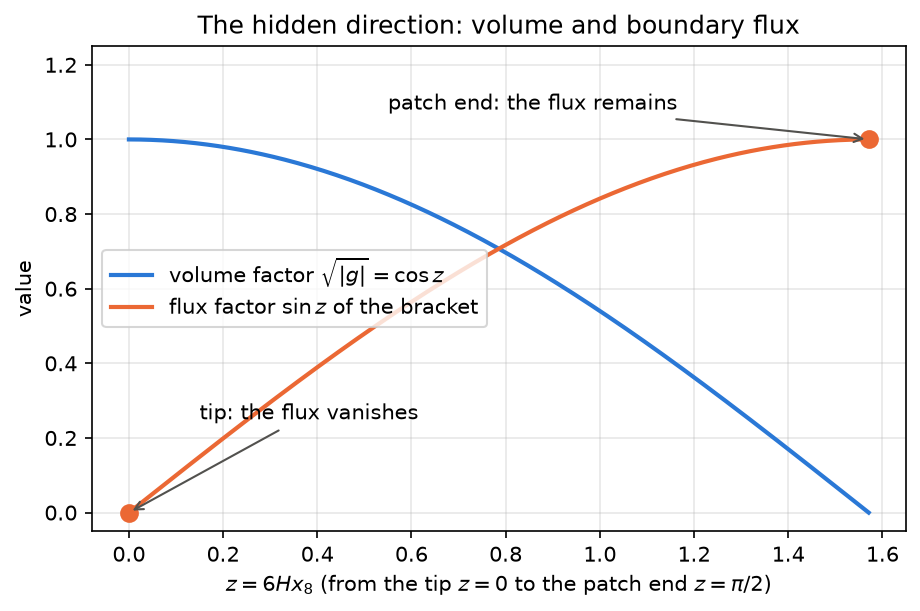

Figure 10d.1 saved as Revision/textbook/figures/10d_1_volume_and_flux.png


In [4]:
G48 = gamma[4] @ gamma[8]  # gamma^(x4) gamma^(x8), real
symmetric_square = np.array_equal(G48, G48.T) and np.array_equal(G48 @ G48,
                                                                  np.eye(16))
e_first = np.eye(16)[:, 0]
u_flux = e_first + G48 @ e_first  # an eigenvector of G48 with eigenvalue +1
M8_numbers = 1j * G48
flux_value = u_flux.conj() @ M8_numbers @ u_flux
report("u^dagger u for the column u = e_1 + gamma4 gamma8 e_1", f"{u_flux @ u_flux:.1f}")
report("flux u^dagger M8 u at z = pi/2",
       f"{flux_value.imag:.1f} i (real part {abs(flux_value.real):.1f})")
check_record(symmetric_square and np.allclose(G48 @ u_flux, u_flux)
             and abs(flux_value - 2j) < 1e-14,
             "the flux at z = pi/2 is u^dagger M8 u = 2 i for gamma4 gamma8 u = u",
             record="Revision/theory/reports/python-scope.json, check "
                    "good_sector_hermiticity_up_to_the_brane_flux")

z_values = np.linspace(0.0, np.pi / 2, 400)
fig, ax = plt.subplots()
ax.plot(z_values, np.cos(z_values), color=BLUE, linewidth=2,
        label="volume factor $\\sqrt{|g|} = \\cos z$")
ax.plot(z_values, np.sin(z_values), color=ORANGE, linewidth=2,
        label="flux factor $\\sin z$ of the bracket")
ax.plot([0.0], [0.0], "o", color=ORANGE, markersize=8)
ax.plot([np.pi / 2], [1.0], "o", color=ORANGE, markersize=8)
ax.annotate("tip: the flux vanishes", (0.0, 0.0), xytext=(0.15, 0.25),
            arrowprops={"arrowstyle": "->", "color": GREY})
ax.annotate("patch end: the flux remains", (np.pi / 2, 1.0), xytext=(0.55, 1.08),
            arrowprops={"arrowstyle": "->", "color": GREY})
ax.set_xlabel("$z = 6 H x_8$ (from the tip $z = 0$ to the patch end $z = \\pi/2$)")
ax.set_ylabel("value")
ax.set_ylim(-0.05, 1.25)
ax.set_title("The hidden direction: volume and boundary flux")
ax.legend(loc="center left")
save_figure(fig, "volume_and_flux",
            "Along the hidden direction, $z = 6Hx_8$ from the tip $z = 0$ to the "
            "patch end $z = \\pi/2$ (horizontal axis): the volume factor $\\sqrt{|g|}"
            " = \\cos z$ of the author's metric (blue) and the factor $\\sin z$ of "
            "the boundary bracket $\\sin z\\,u^\\dagger M_8 v$ (orange); vertical "
            "axis: pure numbers. The volume vanishes at the patch end, but the "
            "bracket there is $u^\\dagger M_8 v$, for example $2i$ for the recorded "
            "column: the mode operator is symmetric, and the Krein charge "
            "conserved, only if a boundary condition removes this flux at $z = "
            "\\pi/2$.")

The next cell makes the role of the spin-connection term visible for one pair of
wave functions, here $u = v$ (the test function $u$ of Section 6) at $m = H = 1$:
it evaluates along $0 < z < \pi/2$ the left-hand side $\cos z\,[u^\dagger(hu) -
(hu)^\dagger u]$, the right-hand side $\partial_8(\sin z\,u^\dagger M_8u)$, and the
left-hand side computed WITHOUT the term $3H$. For $u = v$ all three are purely
imaginary (a number minus its complex conjugate), so their imaginary parts are
plotted. The exact expressions are turned into fast numerical functions with
`sp.lambdify`.

RESULT largest |left - right| on the grid = 5.7e-13
PASS numerical: the two sides agree along the hidden direction


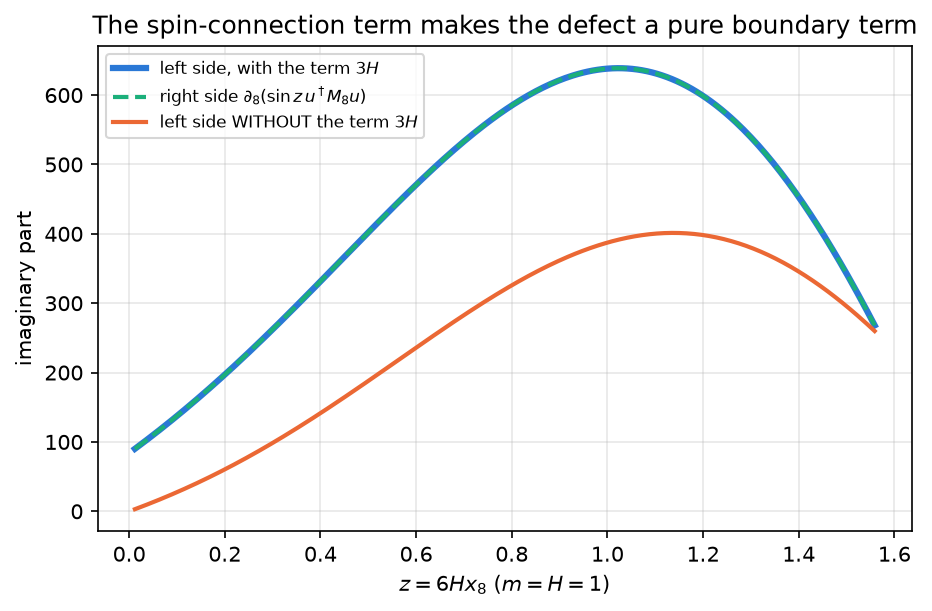

Figure 10d.2 saved as Revision/textbook/figures/10d_2_symmetry_defect.png


In [5]:
numbers = {m: 1, H: 1}  # m = H = 1, so z = 6 x8
hu_full, hu_bare = apply_h(A, u), apply_h(A_no_connection, u)
left = sp.cos(z) * ((u.H * hu_full)[0] - (hu_full.H * u)[0])
right = sp.diff(sp.sin(z) * (u.H * M8 * u)[0], x8)
left_bare = sp.cos(z) * ((u.H * hu_bare)[0] - (hu_bare.H * u)[0])
x8_values = np.linspace(0.002, np.pi / 12 - 0.002, 300)  # inside 0 < z < pi/2
curves = [np.imag(sp.lambdify(x8, e.subs(numbers), "numpy")(x8_values))
          for e in (left, right, left_bare)]
difference = np.max(np.abs(curves[0] - curves[1]))
report("largest |left - right| on the grid", f"{difference:.1e}")
check(difference < 1e-9, "numerical: the two sides agree along the hidden direction")

fig, ax = plt.subplots()
ax.plot(6 * x8_values, curves[0], color=BLUE, linewidth=3,
        label="left side, with the term $3H$")
ax.plot(6 * x8_values, curves[1], "--", color=GREEN, linewidth=2,
        label="right side $\\partial_8(\\sin z\\,u^\\dagger M_8 u)$")
ax.plot(6 * x8_values, curves[2], color=ORANGE, linewidth=2,
        label="left side WITHOUT the term $3H$")
ax.set_xlabel("$z = 6 H x_8$ ($m = H = 1$)")
ax.set_ylabel("imaginary part")
ax.set_title("The spin-connection term makes the defect a pure boundary term")
ax.legend(fontsize=8)
save_figure(fig, "symmetry_defect",
            "For one concrete wave function $u(x_8)$ (16 entries of the form $a + "
            "b\\sin z + c\\cos z$) and $m = H = 1$: the imaginary parts of the "
            "symmetry defect $\\cos z\\,(u^\\dagger(hu) - (hu)^\\dagger u)$ of the "
            "curved good-sector mode operator (blue), of the derivative "
            "$\\partial_8(\\sin z\\,u^\\dagger M_8u)$ (green dashed, on top of the "
            "blue curve), and of the defect of the operator without the "
            "spin-connection term $3H$ (orange), against $z$ (horizontal axis). "
            "With the term the defect is exactly a derivative, whose integral "
            "is the flux at the ends; without it a remainder $-6H\\cos z\\,"
            "u^\\dagger M_8u$ survives.")

## 8. Waves that do not depend on $x_8$: growth for $m < 3H$

For a wave that depends on $x_4$ only, $h$ acts as the constant matrix $A$. The next
cell checks exactly: the norm integral $\int_0^{\pi/(12H)}\cos(6Hx_8)\,dx_8 =
1/(6H)$ is finite; $A$ is not Hermitian; $A^2 = (m^2 - 9H^2)I_{16}$ (the same
cancellation of mixed terms as for the mode Hamiltonian of flat space, because
$\gamma^{(x_4)}$ and $\gamma^{(x_4)}\gamma^{(x_8)}$ anticommute); and at $m = H = 1$
the eigenvalues are $\pm 2\sqrt2\,i$, eight of each (the trace of $A$ is 0).

In [6]:
norm_integral = sp.integrate(sp.cos(6 * H * x8), (x8, 0, sp.pi / (12 * H)))
say(f"integral of cos(6 H x8) over the patch: {norm_integral}")
A_square_ok = (A * A - (m ** 2 - 9 * H ** 2) * sp.eye(16)).applyfunc(
    sp.expand) == zero
A_not_hermitian = (A - A.H).applyfunc(sp.expand) != zero
G48_numbers = gamma[4] @ gamma[8]  # gamma^(x4) gamma^(x8) as numbers


def A_numbers_of(mass, H_value=1.0):
    """The matrix A as numbers: -i m gamma^(x4) + 3 i H gamma^(x4) gamma^(x8)."""
    return -1j * mass * gamma[4] + 3j * H_value * G48_numbers


A_numbers = A_numbers_of(1.0)
eigenvalues = np.linalg.eigvals(A_numbers)
upper = int(np.sum(np.abs(eigenvalues - 2j * np.sqrt(2)) < 1e-9))
lower = int(np.sum(np.abs(eigenvalues + 2j * np.sqrt(2)) < 1e-9))
report("eigenvalues 2 sqrt(2) i and -2 sqrt(2) i at m = H = 1, how many",
       f"{upper} and {lower}")
check_record(norm_integral == 1 / (6 * H) and A_square_ok and A_not_hermitian
             and (upper, lower) == (8, 8),
             "x8-independent waves: A^2 = (m^2 - 9 H^2) I, at m = H = 1: +-2 sqrt(2) i",
             record="Revision/theory/reports/python-scope.json, check "
                    "good_sector_x8_independent_modes_without_boundary_condition")

integral of cos(6 H x8) over the patch: 1/(6*H)
RESULT eigenvalues 2 sqrt(2) i and -2 sqrt(2) i at m = H = 1, how many = 8 and 8
PASS x8-independent waves: A^2 = (m^2 - 9 H^2) I, at m = H = 1: +-2 sqrt(2) i
     reproduces Revision/theory/reports/python-scope.json, check
    good_sector_x8_independent_modes_without_boundary_condition


The next cell draws two figures. The first follows the 16 eigenvalues of $A$ (with
$H = 1$) in the complex plane as $m$ grows from 0 to 5: they are $\pm\sqrt{m^2 -
9H^2}$, on the imaginary axis for $m < 3H$ (growth) and on the real axis for
$m > 3H$ (oscillation). The second shows the growth rate
$\kappa = \sqrt{9H^2 - m^2}$ (zero for $m \geq 3H$) against $m/H$, with the recorded
point $m = H = 1$, $\kappa = 2\sqrt2$.

RESULT largest deviation of |eigenvalue| from sqrt|m^2 - 9| = 4.6e-08
PASS the eigenvalues of A follow +-sqrt(m^2 - 9 H^2)


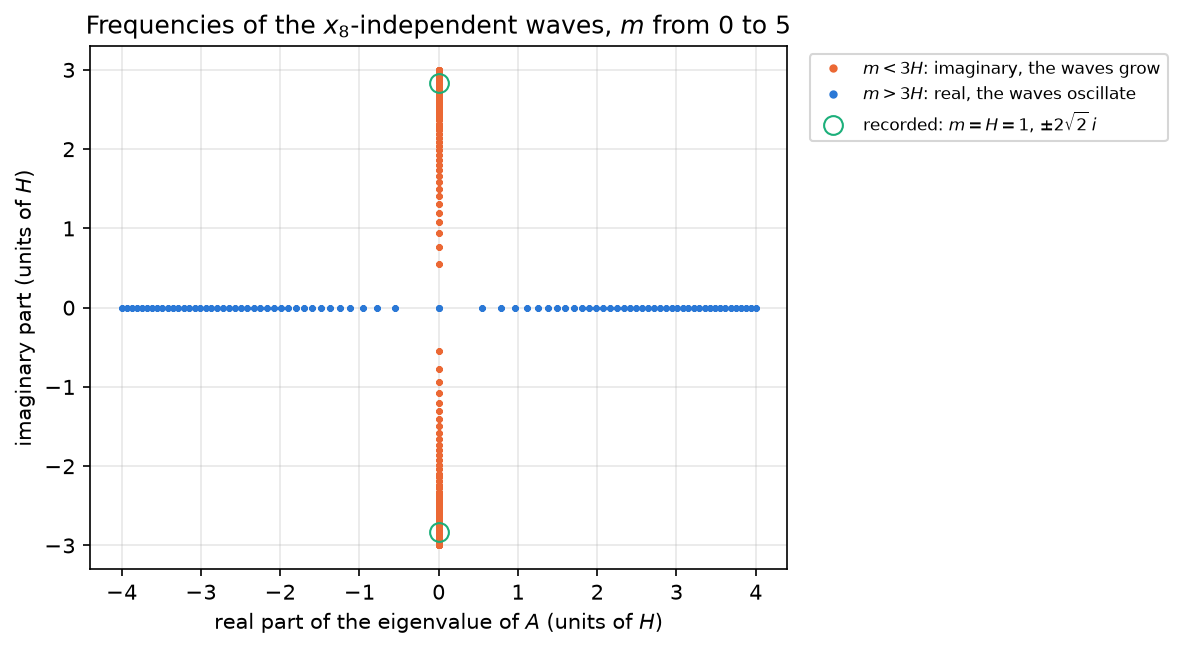

Figure 10d.3 saved as Revision/textbook/figures/10d_3_frequency_paths.png


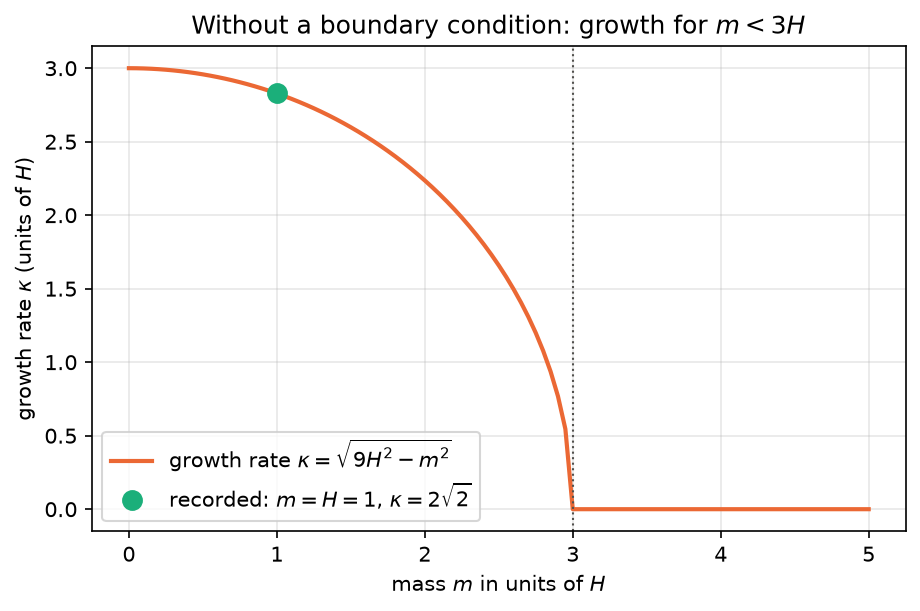

Figure 10d.4 saved as Revision/textbook/figures/10d_4_growth_rate.png


In [7]:
mass_values = np.linspace(0.0, 5.0, 101)
paths = []
for mass in mass_values:
    paths.append(np.linalg.eigvals(A_numbers_of(mass)))
paths = np.array(paths)
worst = np.max(np.abs(np.sort(np.abs(paths), axis=1)
                      - np.sqrt(np.abs(mass_values ** 2 - 9))[:, None]))
report("largest deviation of |eigenvalue| from sqrt|m^2 - 9|", f"{worst:.1e}")
check(worst < 1e-6, "the eigenvalues of A follow +-sqrt(m^2 - 9 H^2)")

fig, ax = plt.subplots(figsize=(6.0, 5.0))
growing = mass_values < 3.0
for column in range(16):
    ax.plot(paths[growing, column].real, paths[growing, column].imag, ".",
            color=ORANGE, markersize=4)
    ax.plot(paths[~growing, column].real, paths[~growing, column].imag, ".",
            color=BLUE, markersize=4)
ax.plot([], [], ".", color=ORANGE, label="$m < 3H$: imaginary, the waves grow")
ax.plot([], [], ".", color=BLUE, label="$m > 3H$: real, the waves oscillate")
ax.plot([0, 0], [2 * np.sqrt(2), -2 * np.sqrt(2)], "o", color=GREEN, markersize=9,
        fillstyle="none", label="recorded: $m = H = 1$, $\\pm 2\\sqrt{2}\\,i$")
ax.set_xlabel("real part of the eigenvalue of $A$ (units of $H$)")
ax.set_ylabel("imaginary part (units of $H$)")
ax.set_aspect("equal")
ax.set_title("Frequencies of the $x_8$-independent waves, $m$ from 0 to 5")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8)  # outside
save_figure(fig, "frequency_paths",
            "The 16 eigenvalues of the matrix $A = -im\\gamma^{(x_4)} + "
            "3iH\\gamma^{(x_4)}\\gamma^{(x_8)}$, which governs the good-sector waves "
            "that do not depend on $x_8$, in the complex plane (horizontal axis: "
            "real part, vertical axis: imaginary part, units of $H$) for $H = 1$ "
            "and the mass $m$ from 0 to 5. For $m < 3H$ (orange) they are "
            "$\\pm i\\sqrt{9H^2 - m^2}$ on the imaginary axis: these finite-norm "
            "waves grow. For $m > 3H$ (blue) they are real. Green circles: the "
            "recorded values $\\pm 2\\sqrt{2}\\,i$ at $m = H = 1$.")

rate = np.sqrt(np.maximum(9.0 - mass_values ** 2, 0.0))
fig, ax = plt.subplots()
ax.plot(mass_values, rate, color=ORANGE, linewidth=2,
        label="growth rate $\\kappa = \\sqrt{9H^2 - m^2}$")
ax.plot([1.0], [2 * np.sqrt(2)], "o", color=GREEN, markersize=9,
        label="recorded: $m = H = 1$, $\\kappa = 2\\sqrt{2}$")
ax.axvline(3.0, color=GREY, linestyle=":", linewidth=1)
ax.set_xlabel("mass $m$ in units of $H$")
ax.set_ylabel("growth rate $\\kappa$ (units of $H$)")
ax.set_title("Without a boundary condition: growth for $m < 3H$")
ax.legend()
save_figure(fig, "growth_rate",
            "The growth rate $\\kappa = \\sqrt{9H^2 - m^2}$ (vertical axis, units of "
            "$H$) of the good-sector waves that do not depend on $x_8$ in the "
            "author's metric, against the mass $m$ (horizontal axis, units of $H$). "
            "It is positive for $m < 3H$ (left of the dotted line) and zero for "
            "$m \\geq 3H$; the green dot is the recorded value $2\\sqrt{2}$ at "
            "$m = H = 1$. These waves have a finite norm, so without a boundary "
            "condition at $z = \\pi/2$ the curved good sector contains growing "
            "waves.")

## 9. An exact growing solution, and where its Krein charge goes

For a wave of $x_4$ alone the equation $i\partial_4\Psi = A\Psi$ reads
$\partial_4\Psi = M\Psi$ with $M = -iA = -m\gamma^{(x_4)} + 3H\gamma^{(x_4)}
\gamma^{(x_8)}$, and $M^2 = (9H^2 - m^2)I = k^2I$. Its solution is $\Psi(x_4) =
e^{Mx_4}\chi = \big(\cosh(kx_4)I + \frac{\sinh(kx_4)}{k}M\big)\chi$ for any constant
column $\chi$: the case $\alpha = 0$ of the exact family of the Revision theory
record. The next cell checks exactly that it solves the full field equation of
Section 4 (with $\partial_8\Psi = 0$).

Then it follows, for $m = H = 1$ ($k = 2\sqrt2$) and a column $\chi$ with
$B\chi = \chi$, the ordinary length $\Psi^\dagger\Psi$ and the Krein charge
$Q(x_4) = \int\cos z\,\Psi^\dagger B\Psi\,dx_8 = \Psi^\dagger B\Psi/(6H)$. By
Section 6 (with $u = v = \Psi$ and $\partial_8\Psi = 0$) the charge changes at the
rate of the flux through the patch end:
$dQ/dx_4 = -i\,[\sin z\,\Psi^\dagger BM_8\Psi]_{z = \pi/2} =
\Psi^\dagger B\gamma^{(x_4)}\gamma^{(x_8)}\Psi$. The cell checks that $Q(x_4) - Q(0)$
equals the flux added up over time (trapezoidal sums on a fine grid).

In [8]:
x4, k = sp.symbols("x4 k", positive=True)
M_exact = -m * g[4] + 3 * H * g[4] * g[8]
chi = sp.Matrix(sp.symbols("q1:17"))  # any constant column
Psi = (sp.cosh(k * x4) * sp.eye(16) + sp.sinh(k * x4) / k * M_exact) * chi
field_equation = g[4] * Psi.diff(x4) + 3 * H * g[8] * Psi - m * Psi  # d8 Psi = 0
# multiply by k, then replace k^2 by 9 H^2 - m^2 (the definition of k)
residual = field_equation.applyfunc(
    lambda e: sp.expand(sp.expand(k * e).subs(k ** 2, 9 * H ** 2 - m ** 2)))
square_ok = (M_exact * M_exact - (9 * H ** 2 - m ** 2) * sp.eye(16)).applyfunc(
    sp.expand) == zero
check_record(square_ok and residual == sp.zeros(16, 1),
             "exact: Psi = (cosh kx4 + sinh(kx4)/k M) chi solves the field equation",
             record="Revision/theory/reports/python-field-theory.json, check "
                    "exact_solution_family_x4_x8")

M_numbers = -1.0 * gamma[4] + 3.0 * G48  # m = H = 1
k_number = np.sqrt(8.0)  # k = sqrt(9 - 1) = 2 sqrt(2)
plus_columns = (np.eye(16) + B) / 2  # columns with B chi = chi (after scaling)
chi_number = plus_columns[:, 0] / np.linalg.norm(plus_columns[:, 0])
x4_values = np.linspace(0.0, 1.5, 3001)
lengths, charges, fluxes = [], [], []
for t in x4_values:
    Psi_t = (np.cosh(k_number * t) * np.eye(16)
             + np.sinh(k_number * t) / k_number * M_numbers) @ chi_number
    lengths.append((Psi_t.conj() @ Psi_t).real)
    charges.append((Psi_t.conj() @ B @ Psi_t).real / 6.0)  # 6 H = 6
    fluxes.append((Psi_t.conj() @ B @ G48 @ Psi_t).real)
lengths, charges, fluxes = map(np.array, (lengths, charges, fluxes))
step = x4_values[1] - x4_values[0]
added_flux = np.concatenate([[0.0], np.cumsum((fluxes[1:] + fluxes[:-1]) / 2) * step])
relative = np.max(np.abs(charges - charges[0] - added_flux)) / np.max(np.abs(charges))
report("Krein charge Q at x4 = 0 and at x4 = 1.5", f"{charges[0]:.6f} and "
       f"{charges[-1]:.3f}")
report("largest relative mismatch of Q(x4) - Q(0) and the added flux",
       f"{relative:.1e}")
check(relative < 1e-5, "the Krein charge changes by the flux through z = pi/2")
growth = np.polyfit(x4_values[1500:], np.log(lengths[1500:]), 1)[0]
report("late slope of ln(Psi^dagger Psi)", f"{growth:.4f} (2 k = {2 * k_number:.4f})")
check(abs(growth - 2 * k_number) < 0.05, "the ordinary length grows like exp(2 k x4)")

PASS exact: Psi = (cosh kx4 + sinh(kx4)/k M) chi solves the field equation
     reproduces Revision/theory/reports/python-field-theory.json, check
    exact_solution_family_x4_x8
RESULT Krein charge Q at x4 = 0 and at x4 = 1.5 = 0.166667 and 454.007
RESULT largest relative mismatch of Q(x4) - Q(0) and the added flux = 6.7e-07
PASS the Krein charge changes by the flux through z = pi/2
RESULT late slope of ln(Psi^dagger Psi) = 5.6600 (2 k = 5.6569)
PASS the ordinary length grows like exp(2 k x4)


The next cell draws the result: the logarithm of the ordinary length (left) and the
Krein charge together with the flux added up over time (right).

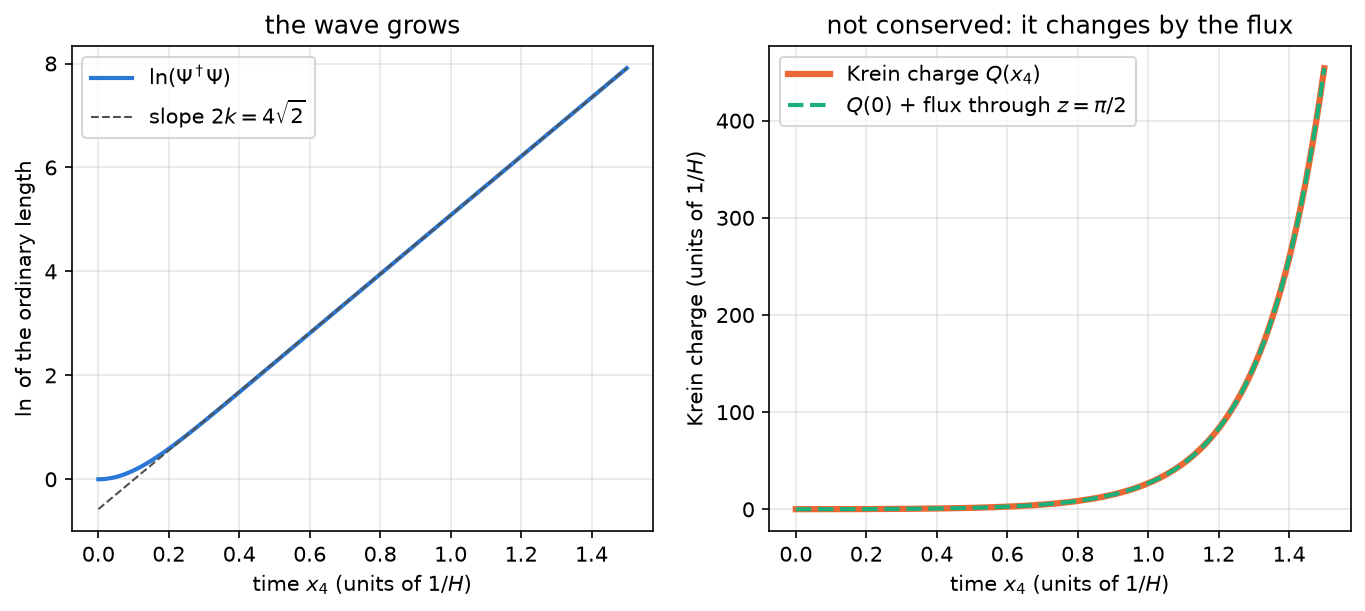

Figure 10d.5 saved as Revision/textbook/figures/10d_5_krein_leak.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))
axes[0].plot(x4_values, np.log(lengths), color=BLUE, linewidth=2,
             label="$\\ln(\\Psi^\\dagger\\Psi)$")
axes[0].plot(x4_values, 2 * k_number * x4_values + np.log(lengths[-1])
             - 2 * k_number * x4_values[-1], "--", color=GREY, linewidth=1,
             label="slope $2k = 4\\sqrt{2}$")
axes[0].set_xlabel("time $x_4$ (units of $1/H$)")
axes[0].set_ylabel("$\\ln$ of the ordinary length")
axes[0].set_title("the wave grows")
axes[0].legend()
axes[1].plot(x4_values, charges, color=ORANGE, linewidth=3,
             label="Krein charge $Q(x_4)$")
axes[1].plot(x4_values, charges[0] + added_flux, "--", color=GREEN, linewidth=2,
             label="$Q(0)$ + flux through $z = \\pi/2$")
axes[1].set_xlabel("time $x_4$ (units of $1/H$)")
axes[1].set_ylabel("Krein charge (units of $1/H$)")
axes[1].set_title("not conserved: it changes by the flux")
axes[1].legend()
save_figure(fig, "krein_leak",
            "The exact good-sector solution $\\Psi(x_4) = (\\cosh kx_4 + \\sinh(kx_4)"
            "/k\\,M)\\chi$, independent of $x_8$, for $m = H = 1$ ($k = 2\\sqrt{2}$) "
            "and a column $\\chi$ with $B\\chi = \\chi$; horizontal axes: the time "
            "$x_4$ in units of $1/H$. Left: the logarithm of its ordinary length "
            "grows with the slope $2k$ (grey dashed line). Right: its Krein charge "
            "$Q = \\int\\cos z\\,\\Psi^\\dagger B\\Psi\\,dx_8$ (orange) is not "
            "constant; it equals its starting value plus the flux through the "
            "patch end $z = \\pi/2$ added up over time (green dashed). Without a "
            "boundary condition at $z = \\pi/2$ the Krein charge is not conserved: "
            "it changes by exactly what passes through the patch end.")

## 10. The last check

The last cell checks that all five figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [10]:
for name in ("10d_1_volume_and_flux.png", "10d_2_symmetry_defect.png",
             "10d_3_frequency_paths.png", "10d_4_growth_rate.png",
             "10d_5_krein_leak.png"):
    check(output_file(f"{FIGURE_FOLDER}/{name}").is_file(),
          f"the figure file {name} exists")
all_checks_passed()

PASS the figure file 10d_1_volume_and_flux.png exists
PASS the figure file 10d_2_symmetry_defect.png exists
PASS the figure file 10d_3_frequency_paths.png exists
PASS the figure file 10d_4_growth_rate.png exists
PASS the figure file 10d_5_krein_leak.png exists
ALL 16 CHECKS PASSED (notebook 10d)


## 11. What this notebook showed

- PROVED (exactly): in the author's metric the good-sector mode operator along the
  hidden direction, $h = -im\gamma^{(x_4)} + 3iH\gamma^{(x_4)}\gamma^{(x_8)} +
  i\tan z\,\gamma^{(x_4)}\gamma^{(x_8)}\partial_8$, satisfies $\cos z\,[u^\dagger(hv)
  - (hu)^\dagger v] = \partial_8(\sin z\,u^\dagger M_8v)$: it is symmetric for the
  volume $\cos z\,dx_8$ only up to a boundary term, which vanishes at the tip but
  not at the patch end $z = \pi/2$ (flux $2i$ for the recorded column). The Krein
  form is conserved up to the analogous term.
- PROVED: the spin-connection term $3H\gamma^{(x_8)}$ is what makes the defect a pure
  boundary term in these variables and this volume; without it the remainder
  $-6H\cos z\,u^\dagger M_8v$ survives. (In other variables, $\Psi = \sin^{-1/2}z\,
  \chi$ with the volume $dy$, no such term is needed: this role of $3H$ depends on
  the variables, as the Revision record states.)
- PROVED: the good-sector waves that do not depend on $x_8$ have a finite norm and
  the frequencies $\pm\sqrt{m^2 - 9H^2}$; for $m < 3H$ they grow (at $m = H = 1$ the
  eigenvalues are $\pm 2\sqrt2\,i$). The exact solution of the record with
  $\alpha = 0$ is such a wave.
- COMPUTED: for that solution the Krein charge is not conserved; it changes by
  exactly the flux through $z = \pi/2$.
- CONSEQUENCE (the scope of the quantisation in the Revision record): Hermiticity of
  the curved good-sector evolution and conservation of the Krein charge need a
  boundary condition at $z = \pi/2$ (for example the ASSUMED brane condition of the
  Kohn-Sham record); the Revision quantisation imposes none. The positive Fock space
  of the previous notebook is built for single good-sector momenta with frozen
  coefficients; a positive Hilbert space for the whole field is not constructed.